Saved CSV -> C:\projects\resilience\pat_sddc_office\Chicago\eui_enduse_breakdown_exact9.csv
Saved PNG -> C:\projects\resilience\pat_sddc_office\Chicago\eui_enduse_stacked_exact9.png

Check: Sum of 9-category EUI vs HTML 'Total Site EUI'
              AEDG Baseline: sum= 30.52 | html= 30.52 | delta=-0.00
          Concrete Envelope: sum= 28.44 | html= 28.44 | delta=+0.00


<Figure size 864x432 with 0 Axes>

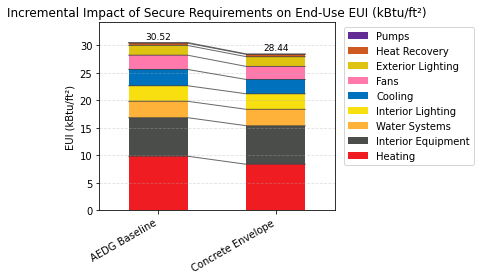

In [1]:
# JUPYTER CELL — Stacked End-Use EUI (match OpenStudio "End Use" pie + colors)

import os, re, math
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb

# ----------------- CONFIG -----------------
ROOT_DIR = Path(r"C:\projects\resilience\pat_sddc_office\Chicago")  # <-- your parent
RUN_ORDER = [
    {"SystemD_baseline": "AEDG Baseline"},
    {"SystemD_extwall_R23": "Concrete Envelope"},
    {"SystemD_extwall_R23_infil": "Tighter Infilration"}
    
    # add more...
]

REPORT_FILENAMES = ["openstudio_results_report.html", "openstudio_results_report.thml"]

# Legend order (top-to-bottom like the screenshot; used for stack ordering)
ENDUSES = [
    "Heating",
    "Interior Equipment",
    "Water Systems",
    "Interior Lighting",
    "Cooling",
    "Fans",
    "Exterior Lighting",
    "Heat Recovery",
    "Pumps",
]

# Exact colors from the OpenStudio pie
COLORS = {
    "Heating": "#EF1C21",
    "Interior Equipment": "#4A4D4A",
    "Water Systems": "#FFB239",
    "Interior Lighting": "#F7DF10",
    "Cooling": "#0071BD",
    "Fans": "#FF79AD",
    "Exterior Lighting": "#DEC310",
    "Heat Recovery": "#CE5921",
    "Pumps": "#632C94",
}

# -------------- HELPERS -------------------
_num = re.compile(r"[-+]?\d[\d,]*\.?\d*")

def parse_number(s: str) -> float:
    m = _num.findall(str(s))
    return float(m[0].replace(",", "")) if m else math.nan

def read_tables(html_path: Path):
    # pandas.read_html needs lxml or html5lib installed
    return pd.read_html(html_path)

def find_model_summary_vals(tables):
    """Return (total_site_eui, total_site_kbtu, total_area_ft2) from Model Summary."""
    site_eui = kbtu = area = math.nan
    for tbl in tables:
        if tbl.shape[1] >= 2:
            first = tbl.iloc[:, 0].astype(str).str.strip()
            # Total Site Energy (kBtu) and Total Building Area (ft^2)
            if first.str.contains(r"^Total Site Energy$", case=False, regex=True).any():
                row = tbl[first.str.contains(r"^Total Site Energy$", case=False, regex=True)].iloc[0]
                kbtu = parse_number(row.iloc[1])
            if first.str.contains(r"^Total Building Area$", case=False, regex=True).any():
                row = tbl[first.str.contains(r"^Total Building Area$", case=False, regex=True)].iloc[0]
                area = parse_number(row.iloc[1])
            if first.str.contains(r"^Total Site EUI$", case=False, regex=True).any():
                row = tbl[first.str.contains(r"^Total Site EUI$", case=False, regex=True)].iloc[0]
                site_eui = parse_number(row.iloc[1])
    return site_eui, kbtu, area

def find_enduse_kbtu(tables):
    """Return dict of end use -> kBtu from the 'End Use – view table'."""
    for tbl in tables:
        cols = [str(c).strip() for c in tbl.columns]
        if len(cols) >= 2 and cols[0].lower().startswith("end use") and "kBtu" in cols[1]:
            df = tbl.copy()
            df.columns = ["End Use", "Consumption (kBtu)"]
            df["End Use"] = df["End Use"].astype(str).str.strip()
            df["Consumption (kBtu)"] = df["Consumption (kBtu)"].map(parse_number).fillna(0.0)
            return dict(zip(df["End Use"], df["Consumption (kBtu)"]))
    raise RuntimeError("Could not find 'End Use – view table' (kBtu).")

def find_reports(root: Path):
    """Find reports in **/reports/ subfolders -> {run_folder_name: report_path}."""
    found = {}
    for dirpath, _, filenames in os.walk(root):
        if Path(dirpath).name.lower() != "reports":
            continue
        for fname in REPORT_FILENAMES:
            if fname in filenames:
                p = Path(dirpath) / fname
                run = Path(dirpath).parent.name  # parent of 'reports'
                found[run] = p
                break
    return found

# -------------- LOAD & COMPUTE ------------
reports = find_reports(ROOT_DIR)

ordered_labels, ordered_reports = [], []
for mapping in RUN_ORDER:
    (folder, display) = next(iter(mapping.items()))
    if folder in reports:
        ordered_labels.append(display)
        ordered_reports.append(reports[folder])
    else:
        print(f"WARNING: folder '{folder}' not found under {ROOT_DIR}")

if not ordered_reports:
    raise SystemExit("No matching reports. Check RUN_ORDER names and the 'reports' subfolders.")

records = []
checks = []   # to compare ΣEUI vs HTML Total Site EUI

for label, rpt in zip(ordered_labels, ordered_reports):
    tables = read_tables(rpt)
    total_site_eui, total_site_kbtu, area_ft2 = find_model_summary_vals(tables)
    enduse_kbtu = find_enduse_kbtu(tables)

    # Build a consistent row for these 9 categories
    row = {"Run": label}
    for eu in ENDUSES:
        val = enduse_kbtu.get(eu, 0.0)
        row[eu] = float(val) / area_ft2  # EUI per end use

    # Keep record
    records.append(row)

    # Check: sum of selected categories vs HTML Total Site EUI
    sum_eui = sum(row[eu] for eu in ENDUSES)
    checks.append((label, sum_eui, total_site_eui))

# DataFrame in chosen left→right order
df = pd.DataFrame(records).set_index("Run")
df = df[ENDUSES]

# -------------- PLOT ----------------------
plt.figure(figsize=(12, 6))
ax = df.plot(kind="bar", stacked=True, color=[COLORS[k] for k in ENDUSES])

# --- CONNECTING LINES ACROSS OUTER EDGES OF THE BARS ---
# get left/right edges from the rectangles of the first stack layer
first_layer = ax.containers[0]            # rectangles for the first end-use across all bars
w = first_layer[0].get_width()
lefts  = [r.get_x() for r in first_layer]
rights = [x + w for x in lefts]

# cumulative tops for each layer (same order as your stacks)
cum = df.cumsum(axis=1)                   # shape: (num_bars, num_layers)

for j, col in enumerate(df.columns):
    y = cum.iloc[:, j].values             # boundary height at each bar

    # Build a polyline that runs along the TOP EDGE of each bar and connects between bars:
    xs, ys = [], []
    for i in range(len(y)):
        xs += [lefts[i], rights[i]]
        ys += [y[i],      y[i]]          # flat across the bar width
    # plot it (edge-to-edge, with slanted connectors between bars)
    ax.plot(xs, ys, color="#444444", linewidth=1.0, alpha=0.8, zorder=5, clip_on=False)

# Optional: bold line for the TOTAL (top of the stack)
#tot = df.sum(axis=1).values
#xs, ys = [], []
#for i in range(len(tot)):
#    xs += [lefts[i], rights[i]]
#    ys += [tot[i],   tot[i]]
#ax.plot(xs, ys, color="#111111", linewidth=1.0, alpha=0.8, zorder=6, clip_on=False)


ax.set_ylabel("EUI (kBtu/ft²)")
ax.set_xlabel("")
ax.set_title("Incremental Impact of Secure Requirements on End-Use EUI (kBtu/ft²)")
#plt.xticks(rotation=30, ha="right", fontsize=10)
fig = plt.gcf()
fig.autofmt_xdate(rotation=30, ha="right")
#plt.xticks(rotation=0, ha="center")
#plt.tight_layout()

ax.grid(axis="y", linestyle="--", alpha=0.4)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1], labels[::-1],
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Totals above bars
#totals = df.sum(axis=1)
#for x, total in zip(ax.get_xticks(), totals):
#    ax.text(x, total, f"{total:.2f}", ha="center", va="bottom", fontsize=9)

# add right after you compute totals
totals = df.sum(axis=1)
ymax = float(totals.max())
ax.set_ylim(0, ymax * 1.12)  # ~12% headroom

# totals above bars with a slight offset
for x, total in zip(ax.get_xticks(), totals):
    ax.text(x, total + ymax*0.01, f"{total:.2f}",  # +1% pad
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
out_csv = ROOT_DIR / "eui_enduse_breakdown_exact9.csv"
out_png = ROOT_DIR / "eui_enduse_stacked_exact9.png"
df.to_csv(out_csv)
plt.savefig(out_png, dpi=200)
print(f"Saved CSV -> {out_csv}")
print(f"Saved PNG -> {out_png}")

# -------------- CHECK OUTPUT --------------
print("\nCheck: Sum of 9-category EUI vs HTML 'Total Site EUI'")
for label, sum_eui, html_eui in checks:
    print(f"  {label:>25s}: sum={sum_eui:6.2f} | html={html_eui:6.2f} | delta={sum_eui - html_eui:+.2f}")
